[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanNece/LABS_ML_Vision_Multimedia/blob/main/Lab01_IntroductionToPyTorch/pytorch_gradient_computation.ipynb)

In [1]:
# numpy and pytorch are already installed
import numpy as np
import torch
# for computational graph visualization
!pip install torchviz

# 🚀 Introduction to Logistic Regression with PyTorch

In this notebook, we are learning how to implement the basic elements of logistic regression using PyTorch. The goal is to understand how PyTorch handles tensors, how automatic differentiation works, and how a simple model computes predictions and loss values step by step.

Logistic regression is one of the simplest forms of machine learning models for binary classification — it predicts whether something belongs to class 0 or class 1.
To do this, the model learns a weight (w) and a bias (b) that together transform the input (x) into a probability value between 0 and 1 through the sigmoid activation function.

### 🧠 Understanding Logistic Regression in PyTorch

In this first part, we start by creating tensors that will be used to represent the components of a very simple logistic regression model. Each tensor is created with the option requires_grad=True, which means PyTorch will automatically keep track of every operation applied to them and will later be able to compute their gradients during backpropagation.

We define:

x as the input feature. In this case it is a single number (2), but in real problems it could be a vector of many features.

y as the true output label. Here it is 1, meaning that the input belongs to the positive class.

w as the weight parameter that the model will learn. It defines how strongly the input influences the prediction.

b as the bias term, which shifts the decision boundary.

Then, we compute the model output using the sigmoid function, which is a smooth mathematical function that converts any real number into a probability between 0 and 1. This step represents the forward pass of the logistic regression model.

Finally, we define the binary cross-entropy loss function, which measures how different the predicted probability is from the true label. A smaller loss means the model is making better predictions. Since the loss is connected to all parameters that require gradients, PyTorch can automatically compute the derivatives of this loss with respect to each parameter during training.

In [ ]:
# variables requiring gradient computation (requires_grad=True)
x = torch.tensor([2.0], requires_grad=True)
y = torch.tensor([1.0], requires_grad=True)
w = torch.tensor([-0.5], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# OUTPUT = SIGMOID FUNCTION
z = 1/(1 + torch.exp(-(w*x+b)))


# BINARY CROSS ENTROPY LOSS FUNCTION
l = -y* torch.log(z) - (1-y) * torch.log(1-z)

This is the predicted output of your logistic regression model — the value of z after applying the sigmoid function.

The sigmoid function transforms the linear combination (w*x + b) into a value between 0 and 1, representing the predicted probability that the input belongs to class 1.

In your case: x = 2.0 / w = -0.5 / b = 0.0

So: `w*x + b = (-0.5)*2 + 0 = -1`

Then,
`z = 1 / (1 + exp(1)) ≈ 0.2689`

👉 Interpretation:
The model predicts that the input x = 2.0 has a 26.9% probability of belonging to class 1.
Since this is below 0.5, the model would classify it as class 0 (negative class).

The part grad_fn=<MulBackward0> indicates that this tensor was created through differentiable operations (multiplication, exponentiation, etc.), so PyTorch is tracking its computation graph and can calculate gradients during backpropagation.

In [6]:
z

tensor([0.2689], grad_fn=<MulBackward0>)

Here:

y = 1, so only the first term matters `(-y * log(z))`

That means the loss becomes `-log(0.2689) ≈ 1.3133`

👉 Interpretation:
This loss tells us how far the prediction (0.2689) is from the true label (1).
A loss of 1.3133 is relatively high, which means the prediction is poor, since the model predicted a low probability (0.27) for something that should have been 1.

During training, optimization algorithms (like Gradient Descent) will adjust w and b to reduce this loss, ideally bringing the predicted probability z closer to 1.

In [3]:
l

tensor([1.3133], grad_fn=<SubBackward0>)

### 🧩 Visualizing the Computational Graph

In this step, we use the Torchviz library to visualize the computational graph that PyTorch builds automatically when we perform differentiable operations on tensors.

Every time we create tensors with requires_grad=True and combine them through mathematical operations (like multiplication, exponentiation, or logarithms), PyTorch keeps track of how each variable contributes to the final output — in this case, the loss l.

`Make_dot()` creates a graphical diagram that shows:

The final output node (the loss l) at the top.

The operations used to compute it (for example MulBackward, ExpBackward, LogBackward, etc.).

The input tensors (x, w, b, and y) at the bottom.

Each arrow in the graph represents how the data and gradients flow through the model during the forward and backward passes.
This visualization helps you understand which operations PyTorch is tracking and how gradients will be propagated when you later call l.backward().

In summary, this diagram gives a clear and visual explanation of how PyTorch automatically builds and connects all computations into a single structure — the computational graph — which is the foundation of automatic differentiation.

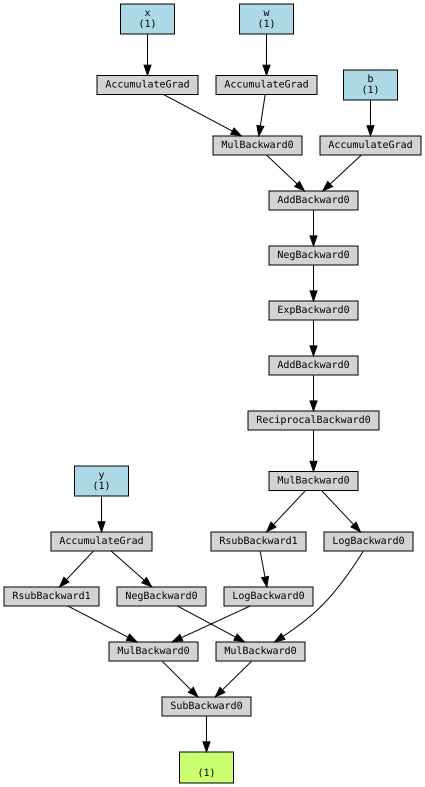

In [4]:
from torchviz import make_dot, make_dot_from_trace
make_dot(l, params={'x':x, 'w':w, 'b':b, 'y':y})

### ⚙️ Backward Pass and Gradient Computation

Now that we have defined the loss function, we can perform the backward pass using `l.backward()`.

This command tells PyTorch to automatically compute the gradients of the loss with respect to every tensor that has requires_grad=True.
Behind the scenes, PyTorch applies the chain rule of calculus through the computational graph we built earlier. Each operation knows how to compute its own local derivative, and PyTorch combines them all to find how each parameter affects the final loss.

After running the backward pass, each tensor (like x, w, and b) now has a new attribute called .grad that stores its gradient value.

In [7]:
#backward pass
l.backward()

In [8]:
print("Backward")
print(f'dL/dx = {x.grad}')
print(f'dL/db = {w.grad}')
print(f'dL/dw = {b.grad}')

Backward
dL/dx = tensor([0.3655])
dL/db = tensor([-1.4621])
dL/dw = tensor([-0.7311])


### 📊 Interpretation of the Results

dL/dx = 0.3655
This is the derivative of the loss with respect to the input x.
***It shows how much the loss would change if we slightly changed the input value.***
In most training scenarios, this gradient is not used directly since x is not a learnable parameter.

dL/dw = -0.7311
This is the gradient of the loss with respect to the weight w.
***A negative value means that if we increase w, the loss will decrease.***
During training, the optimizer will move w slightly upward (because subtracting a negative gradient increases the weight) to reduce the loss.

dL/db = -1.4621
This is the gradient with respect to the bias b.
It indicates that the loss decreases when b increases — again, the optimizer will adjust b accordingly.

### 🧩 Concept Summary

The forward pass computes predictions and the loss.

The backward pass computes how sensitive the loss is to each parameter.

These gradients are the core of learning: an optimizer (like SGD or Adam) will use them to update weights in the direction that minimizes the loss.

This simple example demonstrates PyTorch’s automatic differentiation in action — the foundation that allows deep neural networks to learn through gradient descent.